# Spike Hunter algorithm

Automated Candlestick Spike Pattern Labeling for Cryptocurrency Assets

In [30]:
%pip install pandas numpy matplotlib

25503.23s - pydevd: Sending message related to process being replaced timed-out after 5 seconds



[notice] A new release of pip is available: 24.0 -> 25.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


# Evaluation on a single symbol

Fetching AWEBTC data...
Building features with unified rolling window...
Dataset shape: (479, 47)
Date range: 2025-09-21 00:00:00 to 2025-09-26 01:15:00

=== DATA ANALYSIS ===
Price change statistics:
count    479.000000
mean       0.000815
std        0.015140
min       -0.063636
25%        0.000000
50%        0.000000
75%        0.000000
max        0.129032
Name: price_change, dtype: float64

Volume ratio statistics:
count    479.000000
mean       1.073674
std        1.963276
min        0.000000
25%        0.000000
50%        0.181143
75%        1.225013
max       11.681662
Name: volume_ratio, dtype: float64

Trades ratio statistics:
count    479.000000
mean       1.051286
std        1.726312
min        0.000000
25%        0.000000
50%        0.365482
75%        1.290449
max       11.333326
Name: trades_ratio, dtype: float64

Quote volume ratio statistics:
count    479.000000
mean       1.076257
std        1.967516
min        0.000000
25%        0.000000
50%        0.173918
75%       

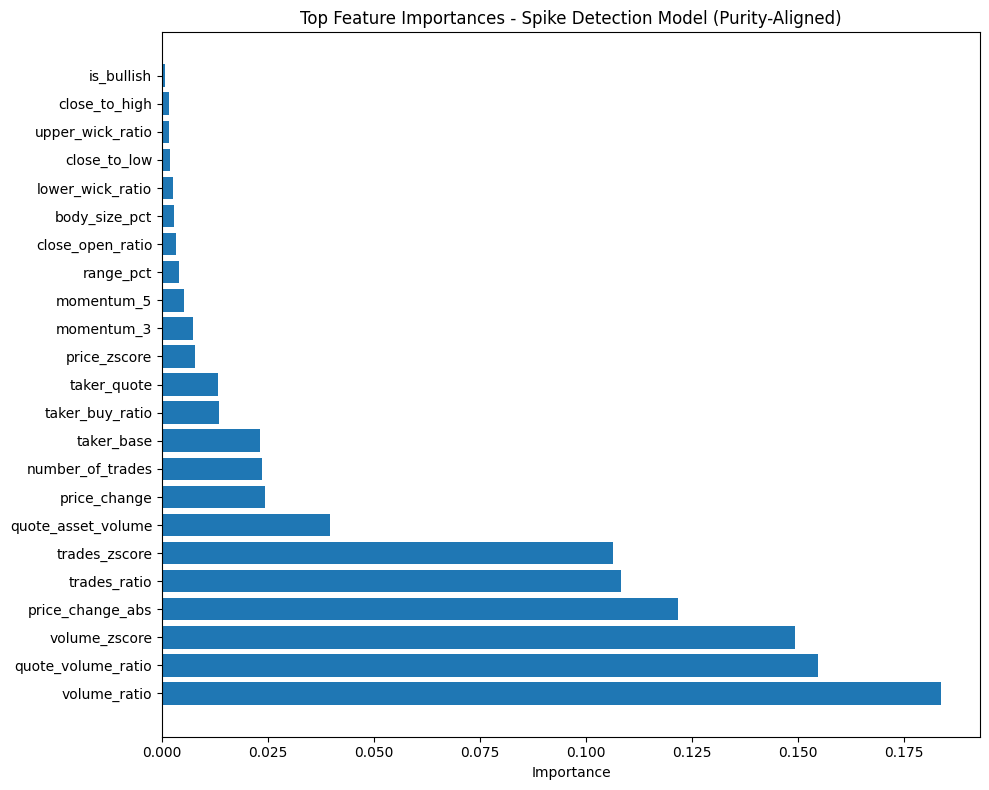


=== PLOTTING RESULTS ===


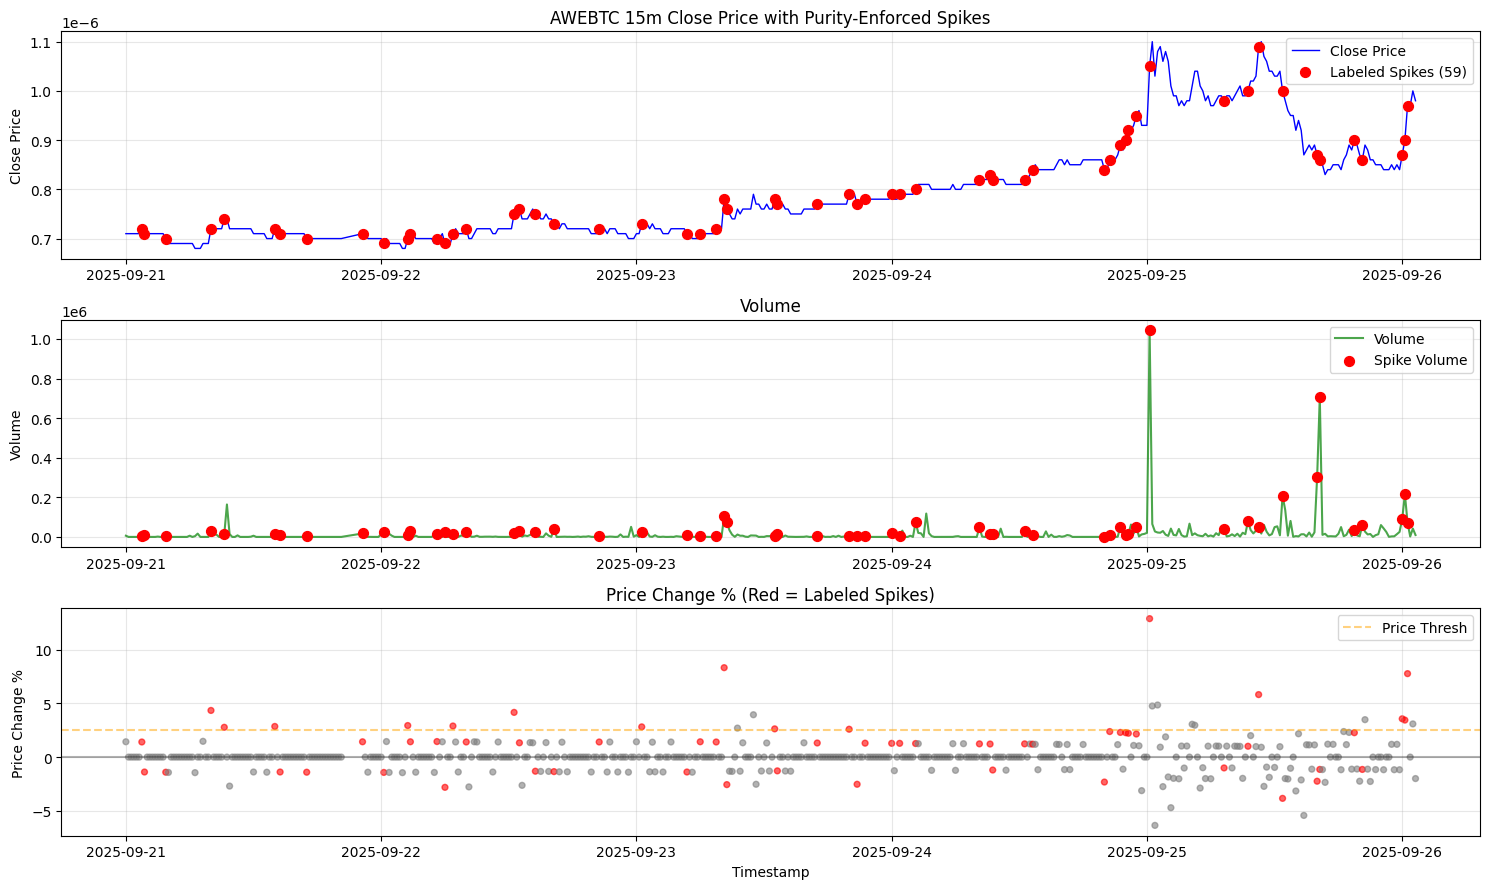


=== SPIKE DETAILS (Last 10) ===
              timestamp  close  price_change  volume_ratio  trades_ratio  \
415 2025-09-25 09:30:00    0.0        0.0101        3.8088        1.9787   
419 2025-09-25 10:30:00    0.0        0.0583        2.1066        2.7023   
428 2025-09-25 12:45:00    0.0       -0.0385        4.5894        2.6383   
441 2025-09-25 16:00:00    0.0       -0.0225        7.6889        5.5107   
442 2025-09-25 16:15:00    0.0       -0.0115        7.2288        6.5590   
455 2025-09-25 19:30:00    0.0        0.0227        2.3280        1.3333   
458 2025-09-25 20:15:00    0.0       -0.0115        3.1543        0.9796   
473 2025-09-26 00:00:00    0.0        0.0357        3.7969        4.0000   
474 2025-09-26 00:15:00    0.0        0.0345        5.1504        5.1679   
475 2025-09-26 00:30:00    0.0        0.0778        1.5438        2.5000   

     quote_volume_ratio  label_price_volume  label_momentum_cluster  \
415              3.7753                   0                

In [31]:
import pandas as pd
import numpy as np
import requests
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import joblib

symbol = "AWEBTC"

# ================= Unified Fixed Windows & Threshold Constants ================= #
ROLLING_WINDOW = 12  # single rolling window used in both training & production
MOMENTUM_LOOKBACK = 3
MOMENTUM_THRESHOLD = 0.015
RSI_OVERSOLD = 30

# Spike base thresholds (price + volume core spike definition)
FIXED_PRICE_THRESHOLD = 0.025  # 2.5% move
FIXED_VOLUME_THRESHOLD = 2.5   # 2.5x recent volume

# Extended mechanism thresholds (now also used in labeling so model aligns with production)
TRADES_RATIO_THRESHOLD = 2.5
QUOTE_VOLUME_RATIO_THRESHOLD = 2.5
MIN_PRICE_MOVE_FOR_ACTIVITY = 0.004   # 0.4% minimum price move to validate trades/quote-only surge
VOLUME_CONFIRM_THRESHOLD = 1.2        # minimum volume ratio confirmation for any spike

# ============================================================================= #

# --- Step 1: Fetch 15m candles from Binance ---
def fetch_binance_klines(symbol="IDEXUSDC", interval="15m", limit=500, end_time=None):
    url = "https://api.binance.com/api/v3/klines"
    params = {"symbol": symbol, "interval": interval, "limit": limit}
    if end_time:
        params["endTime"] = end_time
    resp = requests.get(url, params=params)
    data = resp.json()
    df = pd.DataFrame(
        data,
        columns=[
            "open_time",
            "open",
            "high",
            "low",
            "close",
            "volume",
            "close_time",
            "quote_asset_volume",
            "number_of_trades",
            "taker_base",
            "taker_quote",
            "ignore",
        ],
    )
    numeric_cols = [
        "open",
        "high",
        "low",
        "close",
        "volume",
        "quote_asset_volume",
        "taker_base",
        "taker_quote",
        "number_of_trades",
    ]
    df[numeric_cols] = df[numeric_cols].astype(float)
    df["timestamp"] = pd.to_datetime(df["open_time"], unit="ms")
    df = df[
        [
            "timestamp",
            "open",
            "high",
            "low",
            "close",
            "volume",
            "quote_asset_volume",
            "taker_base",
            "taker_quote",
            "number_of_trades",
        ]
    ]
    return df.sort_values("timestamp").reset_index(drop=True)

# --- (Legacy) Step 2: Fetch ADR data (retained but unused in labeling now) ---
def fetch_adr_series(size=500):
    url = f"https://api.terminal.binbot.in/charts/adr-series?size={size}"
    resp = requests.get(url)
    j = resp.json()
    df_adr = pd.DataFrame(
        {
            "timestamp": pd.to_datetime(j["data"]["timestamp"]),
            "adp_ma": j["data"]["adp_ma"],
            "advancers": j["data"]["advancers"],
            "decliners": j["data"]["decliners"],
            "adp": j["data"]["adp"],
            "total_volume": j["data"]["total_volume"],
        }
    )
    return df_adr

# --- Utility: RSI ---
def calculate_rsi(df, window=14):
    df = df.copy()
    delta = df["close"].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=window).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=window).mean()
    rs = gain / loss
    df["rsi"] = 100 - (100 / (1 + rs))
    return df

# --- Step 3: Extended multi-mechanism labeling aligned with production ---
def label_spike_patterns(
    df: pd.DataFrame,
    price_thresh: float = FIXED_PRICE_THRESHOLD,
    vol_ratio_thresh: float = FIXED_VOLUME_THRESHOLD,
    momentum_thresh: float = MOMENTUM_THRESHOLD,
    momentum_lookback: int = MOMENTUM_LOOKBACK,
    rsi_oversold: int = RSI_OVERSOLD,
    trades_ratio_thresh: float = TRADES_RATIO_THRESHOLD,
    quote_volume_ratio_thresh: float = QUOTE_VOLUME_RATIO_THRESHOLD,
    min_price_for_activity: float = MIN_PRICE_MOVE_FOR_ACTIVITY,
    volume_confirm_threshold: float = VOLUME_CONFIRM_THRESHOLD,
) -> pd.DataFrame:
    """
    Build mechanism-aligned labels so training matches production semantics while enforcing
    purity: every positive label must have at least volume confirmation AND non-trivial price move.

    Mechanism flags produced:
      label_price_volume       : price_change > price_thresh & volume_ratio > vol_ratio_thresh
      label_momentum_cluster   : >=2 of last (momentum_lookback+1) candles exceed momentum_thresh & sum > price_thresh
      label_rsi_reversal       : RSI oversold cross + small upward price move
      label_trades_activity    : trades_ratio surge + min price move + some base volume support
      label_quote_liquidity    : quote_volume_ratio surge + min price move + some base volume support

    Final label = 1 if ANY mechanism flag ==1 AND volume_ratio >= volume_confirm_threshold.
    """
    df = df.copy()

    # Ensure prerequisite columns exist
    required_cols = ["price_change", "volume_ratio", "rsi", "trades_ratio", "quote_volume_ratio"]
    for c in required_cols:
        if c not in df.columns:
            df[c] = 0.0

    n = len(df)
    # Initialize mechanism columns
    mech_cols = [
        "label_price_volume",
        "label_momentum_cluster",
        "label_rsi_reversal",
        "label_trades_activity",
        "label_quote_liquidity",
    ]
    for mc in mech_cols:
        df[mc] = 0

    # Iterate once (vectorization for some parts, loops for temporal dependencies)
    for i in range(n):
        if i == 0:
            continue
        price_change = df.loc[i, "price_change"]
        vol_ratio = df.loc[i, "volume_ratio"]

        # Mechanism 1: Price + Volume
        if price_change > price_thresh and vol_ratio > vol_ratio_thresh:
            df.at[i, "label_price_volume"] = 1

        # Mechanism 2: Momentum cluster
        look_start = max(0, i - momentum_lookback)
        recent = df.loc[look_start:i, "price_change"]
        if (
            len(recent) >= momentum_lookback
            and (recent > momentum_thresh).sum() >= 2
            and recent.sum() > price_thresh
        ):
            df.at[i, "label_momentum_cluster"] = 1

        # Mechanism 3: RSI oversold reversal
        if i >= 14:
            prev_rsi = df.loc[i - 1, "rsi"]
            curr_rsi = df.loc[i, "rsi"]
            if (
                prev_rsi < rsi_oversold
                and curr_rsi > prev_rsi + 5
                and price_change > 0.005
            ):
                df.at[i, "label_rsi_reversal"] = 1

        # Mechanism 4: Trades activity surge (with price + some volume confirmation)
        if (
            df.loc[i, "trades_ratio"] > trades_ratio_thresh
            and abs(price_change) > min_price_for_activity
            and vol_ratio > volume_confirm_threshold * 0.8
        ):
            df.at[i, "label_trades_activity"] = 1

        # Mechanism 5: Quote liquidity surge (with price + some volume confirmation)
        if (
            df.loc[i, "quote_volume_ratio"] > quote_volume_ratio_thresh
            and abs(price_change) > min_price_for_activity
            and vol_ratio > volume_confirm_threshold * 0.8
        ):
            df.at[i, "label_quote_liquidity"] = 1

    # Purity gate: require baseline volume confirmation AND some price move > minimal threshold
    df["_preliminary_any"] = df[mech_cols].sum(axis=1) > 0
    df["label"] = (
        df["_preliminary_any"]
        & (df["volume_ratio"] >= volume_confirm_threshold)
        & (df["price_change_abs"] >= min_price_for_activity)
    ).astype(int)

    return df

# --- Step 4: Enhanced feature engineering (fixed window) ---
def add_enhanced_features(df_price, df_adr=None, window=ROLLING_WINDOW):
    df = df_price.copy().sort_values("timestamp").reset_index(drop=True)

    eff = window  # fixed, no adaptive shrinking to align with production purity

    # Basic price features
    df["price_change"] = df["close"].pct_change()
    df["price_change_abs"] = df["price_change"].abs()

    # Candle anatomy
    df["body_size"] = (df["close"] - df["open"]).abs()
    df["body_size_pct"] = df["body_size"] / (df["open"] + 1e-6)
    df["upper_wick"] = df["high"] - df[["close", "open"]].max(axis=1)
    df["lower_wick"] = df[["close", "open"]].min(axis=1) - df["low"]
    df["upper_wick_ratio"] = df["upper_wick"] / (df["body_size"] + 1e-6)
    df["lower_wick_ratio"] = df["lower_wick"] / (df["body_size"] + 1e-6)
    df["total_range"] = df["high"] - df["low"]
    df["range_pct"] = df["total_range"] / (df["open"] + 1e-6)

    # Direction / trend
    df["is_bullish"] = (df["close"] > df["open"]).astype(int)
    df["close_open_ratio"] = (df["close"] - df["open"]) / (df["open"] + 1e-6)

    # Rolling stats
    df["price_ma"] = df["close"].rolling(eff).mean()
    df["price_std"] = df["close"].rolling(eff).std()
    df["price_zscore"] = (df["close"] - df["price_ma"]) / (df["price_std"] + 1e-6)

    # Volume (base)
    df["volume_ma"] = df["volume"].rolling(eff).mean()
    df["volume_ratio"] = df["volume"] / (df["volume_ma"] + 1e-6)
    df["volume_zscore"] = (df["volume"] - df["volume_ma"]) / (df["volume"].rolling(eff).std() + 1e-6)

    # Quote asset volume
    if "quote_asset_volume" in df.columns:
        df["quote_volume_ma"] = df["quote_asset_volume"].rolling(eff).mean()
        df["quote_volume_ratio"] = df["quote_asset_volume"] / (df["quote_volume_ma"] + 1e-6)
    else:
        df["quote_volume_ma"] = 0.0
        df["quote_volume_ratio"] = 0.0

    # Trades activity
    if "number_of_trades" in df.columns:
        df["trades_ma"] = df["number_of_trades"].rolling(eff).mean()
        df["trades_ratio"] = df["number_of_trades"] / (df["trades_ma"] + 1e-6)
        df["trades_zscore"] = (df["number_of_trades"] - df["trades_ma"]) / (df["number_of_trades"].rolling(eff).std() + 1e-6)
    else:
        df["trades_ma"] = 0.0
        df["trades_ratio"] = 0.0
        df["trades_zscore"] = 0.0

    # Momentum
    df["momentum_3"] = df["close"].pct_change(3)
    df["momentum_5"] = df["close"].pct_change(5)

    # High/Low proximity
    df["high_low_ratio"] = df["high"] / (df["low"] + 1e-6)
    df["close_to_high"] = (df["high"] - df["close"]) / (df["high"] + 1e-6)
    df["close_to_low"] = (df["close"] - df["low"]) / (df["close"] + 1e-6)

    # Order flow
    if "taker_base" in df.columns:
        df["taker_buy_ratio"] = df["taker_base"] / (df["volume"] + 1e-6)
    else:
        df["taker_buy_ratio"] = 0.0

    # RSI
    df = calculate_rsi(df, window=14)

    df = df.dropna().reset_index(drop=True)
    df = label_spike_patterns(df)
    return df

# --- Data fetching and analysis ---
print(f"Fetching {symbol} data...")
df_price = fetch_binance_klines(symbol, interval="15m", limit=500)

# ADR fetch retained (optional)
try:
    df_adr = fetch_adr_series(size=500)
except Exception:
    df_adr = None

print("Building features with unified rolling window...")
df = add_enhanced_features(df_price, df_adr, window=ROLLING_WINDOW)

print(f"Dataset shape: {df.shape}")
print(f"Date range: {df['timestamp'].min()} to {df['timestamp'].max()}")

print("\n=== DATA ANALYSIS ===")
print("Price change statistics:")
print(df["price_change"].describe())
print("\nVolume ratio statistics:")
print(df["volume_ratio"].describe())
print("\nTrades ratio statistics:")
print(df["trades_ratio"].describe())
print("\nQuote volume ratio statistics:")
print(df["quote_volume_ratio"].describe())

label_counts = np.bincount(df["label"].astype(int))
print(f"\nLabel distribution: {dict(enumerate(label_counts))}")
rate = label_counts[1] / max(1, (label_counts[0] + label_counts[1]))
print(f"Spike detection rate: {rate:.4f}")

if label_counts[1] > 0:
    spike_examples = df[df["label"] == 1][[
        "timestamp","open","close","price_change","volume_ratio","trades_ratio","quote_volume_ratio","body_size_pct","taker_buy_ratio"
    ]].head(10)
    print("\nFirst 10 labeled spikes (purity enforced):")
    print(spike_examples)

# --- Model Training ---
feature_cols = [
    "price_change","price_change_abs","body_size_pct","upper_wick_ratio","lower_wick_ratio","is_bullish","close_open_ratio","price_zscore","volume_ratio","volume_zscore","momentum_3","momentum_5","range_pct","close_to_high","close_to_low","taker_base","taker_quote","taker_buy_ratio","quote_asset_volume","number_of_trades","trades_ratio","trades_zscore","quote_volume_ratio"
]

available_features = [col for col in feature_cols if col in df.columns]
print(f"\nUsing features: {available_features}")

X = df[available_features]
y = df["label"]
print(f"Final label counts: {np.bincount(y.astype(int)) if len(y) > 0 else 'empty'}")

if len(np.unique(y)) < 2:
    print("Not enough positive examples after purity gating. Consider relaxing one of:")
    print(f"- FIXED_PRICE_THRESHOLD (currently {FIXED_PRICE_THRESHOLD})")
    print(f"- FIXED_VOLUME_THRESHOLD (currently {FIXED_VOLUME_THRESHOLD})")
    print(f"- VOLUME_CONFIRM_THRESHOLD (currently {VOLUME_CONFIRM_THRESHOLD})")
    print(f"- MIN_PRICE_MOVE_FOR_ACTIVITY (currently {MIN_PRICE_MOVE_FOR_ACTIVITY})")
else:
    from sklearn.utils.class_weight import compute_class_weight
    class_weights = compute_class_weight("balanced", classes=np.unique(y), y=y)
    class_weight_dict = dict(zip(np.unique(y), class_weights))
    print(f"Using class weights: {class_weight_dict}")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42
    )

    clf = RandomForestClassifier(
        n_estimators=250,
        max_depth=12,
        min_samples_split=4,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=42,
    )
    clf.fit(X_train, y_train)

    y_pred = clf.predict(X_test)
    y_pred_proba = clf.predict_proba(X_test)[:, 1]

    print("\n=== MODEL EVALUATION ===")
    print("Classification Report:")
    print(classification_report(y_test, y_pred, digits=4))

    import os
    os.makedirs("../checkpoints", exist_ok=True)
    joblib.dump(clf, "../checkpoints/spikehunter_model_v2.pkl")

    importances = clf.feature_importances_
    feature_importance_df = pd.DataFrame({"feature": available_features, "importance": importances}).sort_values("importance", ascending=False)
    print("\nTop 10 Feature Importances:")
    print(feature_importance_df.head(10))

    plt.figure(figsize=(10, 8))
    plt.barh(feature_importance_df.head(25)["feature"], feature_importance_df.head(25)["importance"])
    plt.title("Top Feature Importances - Spike Detection Model (Purity-Aligned)")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()

print("\n=== PLOTTING RESULTS ===")
plt.figure(figsize=(15, 9))
plt.subplot(3, 1, 1)
plt.plot(df["timestamp"], df["close"], label="Close Price", color="blue", linewidth=1)
spike_indices = df.index[df["label"] == 1]
if len(spike_indices) > 0:
    plt.scatter(df.loc[spike_indices, "timestamp"], df.loc[spike_indices, "close"], color="red", label=f"Labeled Spikes ({len(spike_indices)})", zorder=5, s=50)
plt.title(f"{symbol} 15m Close Price with Purity-Enforced Spikes")
plt.ylabel("Close Price")
plt.legend(); plt.grid(True, alpha=0.3)

plt.subplot(3, 1, 2)
plt.plot(df["timestamp"], df["volume"], label="Volume", color="green", alpha=0.7)
if len(spike_indices) > 0:
    plt.scatter(df.loc[spike_indices, "timestamp"], df.loc[spike_indices, "volume"], color="red", label="Spike Volume", zorder=5, s=50)
plt.title("Volume")
plt.ylabel("Volume")
plt.legend(); plt.grid(True, alpha=0.3)

plt.subplot(3, 1, 3)
colors = ["red" if x == 1 else "gray" for x in df["label"]]
plt.scatter(df["timestamp"], df["price_change"] * 100, c=colors, alpha=0.6, s=18)
plt.axhline(y=0, color="black", linestyle="-", alpha=0.3)
plt.axhline(y=FIXED_PRICE_THRESHOLD*100, color="orange", linestyle="--", alpha=0.5, label="Price Thresh")
plt.title("Price Change % (Red = Labeled Spikes)")
plt.xlabel("Timestamp")
plt.ylabel("Price Change %")
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

if len(spike_indices) > 0:
    print("\n=== SPIKE DETAILS (Last 10) ===")
    spike_details = df.loc[spike_indices, [
        "timestamp","close","price_change","volume_ratio","trades_ratio","quote_volume_ratio","label_price_volume","label_momentum_cluster","label_trades_activity","label_quote_liquidity"
    ]].tail(10).round(4)
    spike_details["price_change_pct"] = (spike_details["price_change"] * 100).round(2)
    print(spike_details)
else:
    print("\n=== NO SPIKES DETECTED UNDER PURITY RULES ===")
    print("Consider relaxing:")
    print(f"- price_thresh ({FIXED_PRICE_THRESHOLD})")
    print(f"- vol_ratio_thresh ({FIXED_VOLUME_THRESHOLD})")
    print(f"- volume_confirm_threshold ({VOLUME_CONFIRM_THRESHOLD})")
    print(f"- min_price_for_activity ({MIN_PRICE_MOVE_FOR_ACTIVITY})")

try:
    joblib.dump(clf, "../checkpoints/spikehunter_model_v2.pkl")
except NameError:
    pass

# Production Spike Hunter
Unified spike detection system for cryptocurrency trading.
- Full-featured production analysis (detailed stats, multiple detection methods)
- Standalone last spike detection (recent spike reporting)
- Dynamic thresholding, top-N stats, volatility reporting, and advanced plotting

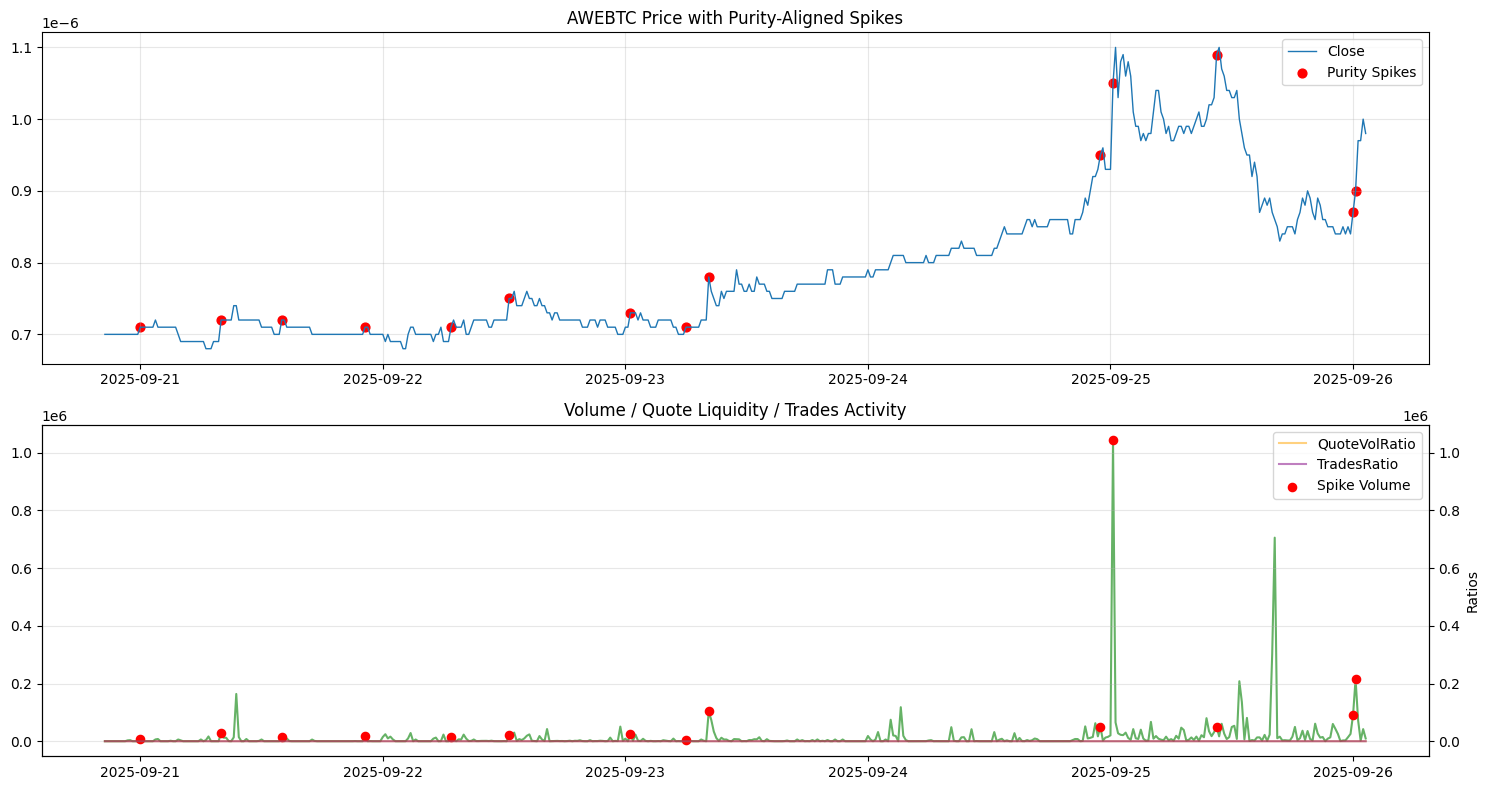

Last spike summary:
  timestamp: 2025-09-26 00:15:00+00:00
  price: 0.0000
  price_change: 0.0345
  price_change_pct: 3.4483
  volume: 215197.0000
  volume_ratio: 5.1504
  quote_asset_volume: 0.1943
  number_of_trades: 118
  trades_ratio: 5.1679
  quote_volume_ratio: 5.3359
  spike_type: price_volume,momentum,trades_activity,quote_liquidity
  mechanism_count: 4
  signal_strength: 5.5328
  rsi: 56.5771
  body_size_pct: 0.0106
  price_std: 0.0000
  price_zscore: 0.0475
  volume_zscore: 2.8497
  minutes_ago: 69.3863


In [32]:
import pandas as pd
import numpy as np
import requests
from typing import Optional, Dict, Tuple
import matplotlib.pyplot as plt
import joblib

# Ensure production uses same constants as training for purity alignment
ROLLING_WINDOW = 12
MOMENTUM_LOOKBACK = 3
MOMENTUM_THRESHOLD = 0.015
RSI_OVERSOLD = 30
FIXED_PRICE_THRESHOLD = 0.025
FIXED_VOLUME_THRESHOLD = 2.5
TRADES_RATIO_THRESHOLD = 2.5
QUOTE_VOLUME_RATIO_THRESHOLD = 2.5
MIN_PRICE_MOVE_FOR_ACTIVITY = 0.004
VOLUME_CONFIRM_THRESHOLD = 1.2

class SpikeHunter:
    """
    Production Spike Hunter (purity-aligned v2)

    Changes for purity:
      - Uses unified fixed rolling window (ROLLING_WINDOW) identical to training
      - Incorporates trades & quote liquidity only if accompanied by minimal price move AND volume confirmation
      - Adds weighted scoring & filters out isolated low-value mechanisms
      - Calibrates ML mechanism with probability threshold rather than raw predict (optional override)
    """

    def __init__(
        self,
        model_path: str,
        momentum_threshold: float = MOMENTUM_THRESHOLD,
        window: int = ROLLING_WINDOW,
        rsi_oversold: int = RSI_OVERSOLD,
        price_threshold: float = FIXED_PRICE_THRESHOLD,
        volume_threshold: float = FIXED_VOLUME_THRESHOLD,
        trades_ratio_threshold: float = TRADES_RATIO_THRESHOLD,
        quote_volume_ratio_threshold: float = QUOTE_VOLUME_RATIO_THRESHOLD,
        ml_proba_threshold: float = 0.65,
        min_price_for_activity: float = MIN_PRICE_MOVE_FOR_ACTIVITY,
        volume_confirm_threshold: float = VOLUME_CONFIRM_THRESHOLD,
    ):
        self.df = pd.DataFrame()
        self.momentum_threshold = momentum_threshold
        self.window = window
        self.rsi_oversold = rsi_oversold
        self.model = joblib.load(model_path)
        self.price_threshold = price_threshold
        self.volume_threshold = volume_threshold
        self.trades_ratio_threshold = trades_ratio_threshold
        self.quote_volume_ratio_threshold = quote_volume_ratio_threshold
        self.ml_proba_threshold = ml_proba_threshold
        self.min_price_for_activity = min_price_for_activity
        self.volume_confirm_threshold = volume_confirm_threshold

        # Mechanism registry: (label, column)
        self.mechanism_cols = [
            ("ml_classifier", "spike_ml_classifier"),
            ("price_volume", "spike_price_volume"),
            ("momentum", "spike_momentum"),
            ("rsi_reversal", "spike_rsi_reversal"),
            ("trades_activity", "spike_trades_activity"),
            ("quote_liquidity", "spike_quote_liquidity"),
        ]
        self.time_windows = [5, 15, 30, 60, 120]

        # Weight schema (price-volume weighted highest)
        self.weights = {
            "spike_price_volume": 2.0,
            "spike_momentum": 1.5,
            "spike_rsi_reversal": 1.5,
            "spike_ml_classifier": 1.0,
            "spike_trades_activity": 0.75,
            "spike_quote_liquidity": 0.75,
        }
        self.required_score = 2.0  # threshold for weighted_score

    # ---------------- Data Fetch ---------------- #
    def fetch_market_data(
        self,
        symbol: str,
        interval: str = "15m",
        limit: int = 500,
        end_time: Optional[int] = None,
    ) -> pd.DataFrame:
        url = "https://api.binance.com/api/v3/klines"
        params = {"symbol": symbol, "interval": interval, "limit": limit}
        if end_time:
            params["endTime"] = end_time
        response = requests.get(url, params=params, timeout=10)
        response.raise_for_status()
        data = response.json()
        df = pd.DataFrame(
            data,
            columns=[
                "open_time","open","high","low","close","volume","close_time","qav","num_trades","taker_base","taker_quote","ignore"
            ],
        )
        df.rename(columns={"qav": "quote_asset_volume", "num_trades": "number_of_trades"}, inplace=True)
        numeric_cols = [
            "open","high","low","close","volume","quote_asset_volume","taker_base","taker_quote","number_of_trades"
        ]
        for c in numeric_cols:
            df[c] = pd.to_numeric(df[c], errors="coerce")
        df["timestamp"] = pd.to_datetime(df["open_time"], unit="ms")
        df = df[["timestamp","open","high","low","close","volume","quote_asset_volume","taker_base","taker_quote","number_of_trades"]]
        return df.sort_values("timestamp").reset_index(drop=True)

    # ---------------- Feature Engineering ---------------- #
    def calculate_rsi(self, prices: pd.Series, window: int = 14) -> pd.Series:
        delta = prices.diff()
        gain = delta.where(delta > 0, 0).rolling(window=window, min_periods=1).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(window=window, min_periods=1).mean()
        rs = gain / (loss + 1e-10)
        return 100 - (100 / (1 + rs))

    def _add_all_features(self, df: pd.DataFrame) -> pd.DataFrame:
        df["price_change"] = df["close"].pct_change()
        df["price_change_abs"] = df["price_change"].abs()
        df["body_size"] = (df["close"] - df["open"]).abs()
        df["body_size_pct"] = df["body_size"] / (df["open"] + 1e-6)
        df["upper_wick"] = df["high"] - df[["close", "open"]].max(axis=1)
        df["lower_wick"] = df[["close", "open"]].min(axis=1) - df["low"]
        df["upper_wick_ratio"] = df["upper_wick"] / (df["body_size"] + 1e-6)
        df["lower_wick_ratio"] = df["lower_wick"] / (df["body_size"] + 1e-6)
        df["total_range"] = df["high"] - df["low"]
        df["range_pct"] = df["total_range"] / (df["open"] + 1e-6)
        df["is_bullish"] = (df["close"] > df["open"]).astype(int)
        df["close_open_ratio"] = (df["close"] - df["open"]) / (df["open"] + 1e-6)

        eff = self.window  # fixed, purity alignment
        df["price_ma"] = df["close"].rolling(eff).mean()
        df["price_std"] = df["close"].rolling(eff).std()
        df["price_zscore"] = (df["close"] - df["price_ma"]) / (df["price_std"] + 1e-6)

        df["volume_ma"] = df["volume"].rolling(eff).mean()
        df["volume_ratio"] = df["volume"] / (df["volume_ma"] + 1e-6)
        df["volume_zscore"] = (df["volume"] - df["volume_ma"]) / (df["volume"].rolling(eff).std() + 1e-6)

        df["quote_volume_ma"] = df["quote_asset_volume"].rolling(eff).mean()
        df["quote_volume_ratio"] = df["quote_asset_volume"] / (df["quote_volume_ma"] + 1e-6)

        df["trades_ma"] = df["number_of_trades"].rolling(eff).mean()
        df["trades_ratio"] = df["number_of_trades"] / (df["trades_ma"] + 1e-6)
        df["trades_zscore"] = (df["number_of_trades"] - df["trades_ma"]) / (df["number_of_trades"].rolling(eff).std() + 1e-6)

        df["momentum_3"] = df["close"].pct_change(3)
        df["momentum_5"] = df["close"].pct_change(5)
        df["high_low_ratio"] = df["high"] / (df["low"] + 1e-6)
        df["close_to_high"] = (df["high"] - df["close"]) / (df["high"] + 1e-6)
        df["close_to_low"] = (df["close"] - df["low"]) / (df["close"] + 1e-6)
        df["rsi"] = self.calculate_rsi(df["close"])

        if "taker_base" in df.columns:
            df["taker_buy_ratio"] = df["taker_base"] / (df["volume"] + 1e-6)
        else:
            df["taker_buy_ratio"] = 0.0

        return df.fillna(0)

    def _get_feature_matrix(self, df: pd.DataFrame) -> pd.DataFrame:
        feature_cols = [
            "price_change","price_change_abs","body_size_pct","upper_wick_ratio","lower_wick_ratio","is_bullish","close_open_ratio","price_zscore","volume_ratio","volume_zscore","momentum_3","momentum_5","range_pct","close_to_high","close_to_low","taker_base","taker_quote","taker_buy_ratio","quote_asset_volume","quote_volume_ratio","number_of_trades","trades_ratio","trades_zscore"
        ]
        for c in feature_cols:
            if c not in df.columns:
                df[c] = 0.0
        return df[feature_cols].fillna(0)

    # ---------------- Mechanisms ---------------- #
    def _apply_ml(self, df, proba):
        df["ml_proba"] = proba
        df["spike_ml_classifier"] = (proba >= self.ml_proba_threshold).astype(int)

    def _apply_price_volume(self, df):
        df["spike_price_volume"] = ((df["price_change"] > self.price_threshold) & (df["volume_ratio"] > self.volume_threshold)).astype(int)

    def _apply_momentum(self, df):
        flags = []
        for i in range(len(df)):
            if i < MOMENTUM_LOOKBACK + 1:
                flags.append(0)
                continue
            recent = df.loc[i-MOMENTUM_LOOKBACK:i, "price_change"]
            if (recent > self.momentum_threshold).sum() >= 2 and recent.sum() > self.price_threshold:
                flags.append(1)
            else:
                flags.append(0)
        df["spike_momentum"] = flags

    def _apply_rsi_reversal(self, df):
        flags = []
        for i in range(len(df)):
            if i < 14:
                flags.append(0)
                continue
            if (df.loc[i-1, "rsi"] <= self.rsi_oversold and df.loc[i, "rsi"] > self.rsi_oversold and df.loc[i, "price_change"] > 0.008):
                flags.append(1)
            else:
                flags.append(0)
        df["spike_rsi_reversal"] = flags

    def _apply_trades_surge(self, df):
        df["spike_trades_activity"] = (
            (df["trades_ratio"] > self.trades_ratio_threshold) &
            (df["price_change_abs"] > self.min_price_for_activity) &
            (df["volume_ratio"] > self.volume_confirm_threshold * 0.8)
        ).astype(int)

    def _apply_quote_liquidity(self, df):
        df["spike_quote_liquidity"] = (
            (df["quote_volume_ratio"] > self.quote_volume_ratio_threshold) &
            (df["price_change_abs"] > self.min_price_for_activity) &
            (df["volume_ratio"] > self.volume_confirm_threshold * 0.8)
        ).astype(int)

    # ---------------- Orchestration ---------------- #
    def detect_spikes(self, symbol: str) -> pd.DataFrame:
        df = self.fetch_market_data(symbol, interval="15m", limit=500)
        if df.empty:
            self.df = df
            return df
        df = self._add_all_features(df)

        # ML probability + predictions
        X = self._get_feature_matrix(df)
        try:
            proba = self.model.predict_proba(X)[:,1]
        except Exception:
            proba = np.zeros(len(df))

        # Initialize mechanism columns
        for _, col in self.mechanism_cols:
            df[col] = 0

        # Apply mechanisms
        self._apply_ml(df, proba)
        self._apply_price_volume(df)
        self._apply_momentum(df)
        self._apply_rsi_reversal(df)
        self._apply_trades_surge(df)
        self._apply_quote_liquidity(df)

        # Weighted scoring
        df["weighted_score"] = 0.0
        for col, w in self.weights.items():
            df["weighted_score"] += df[col] * w

        # Purity gates
        price_gate = df["price_change_abs"] >= self.min_price_for_activity
        volume_gate = df["volume_ratio"] >= self.volume_confirm_threshold

        df["spike_signal"] = (
            (df["weighted_score"] >= self.required_score) & price_gate & volume_gate
        ).astype(int)

        # Remove isolated low-value single-mechanism spikes (e.g., only trades or only quote)
        low_value_only = (
            (df["spike_signal"] == 1) &
            (df[["spike_trades_activity","spike_quote_liquidity"]].sum(axis=1) == 1) &
            (df[["spike_price_volume","spike_momentum","spike_rsi_reversal"]].sum(axis=1) == 0)
        )
        df.loc[low_value_only, "spike_signal"] = 0

        # Recompute mechanism_count for reporting
        mech_cols_only = [c for _, c in self.mechanism_cols]
        df["mechanism_count"] = df[mech_cols_only].sum(axis=1)
        df["spike_type"] = df.apply(lambda r: ",".join([name for name, col in self.mechanism_cols if r[col] == 1]), axis=1)

        df["signal_strength"] = (
            df["weighted_score"] + (df["price_change_abs"] * df["volume_ratio"] * 3).clip(0,5)
        ).clip(0,10)

        if df["spike_signal"].sum() == 0:
            print("[Diagnostics] No spikes after purity gating")
            print(f"Max price_change: {df['price_change'].max():.4f} (threshold {self.price_threshold:.4f})")
            print(f"Max volume_ratio: {df['volume_ratio'].max():.2f} (gate {self.volume_confirm_threshold:.2f})")
            print(f"Max trades_ratio: {df['trades_ratio'].max():.2f} (threshold {self.trades_ratio_threshold:.2f})")
            print(f"Max quote_volume_ratio: {df['quote_volume_ratio'].max():.2f} (threshold {self.quote_volume_ratio_threshold:.2f})")

        self.df = df
        return df

    def _ensure_utc(self, ts: pd.Timestamp) -> pd.Timestamp:
        if not isinstance(ts, pd.Timestamp):
            ts = pd.Timestamp(ts)
        if ts.tzinfo is None:
            return ts.tz_localize("UTC")
        return ts.tz_convert("UTC") if ts.tzinfo != pd.Timestamp.now(tz="UTC").tzinfo else ts

    def run_analysis(self, symbol: str, max_minutes_ago=30) -> Optional[Dict]:
        df = self.detect_spikes(symbol)
        spikes = df[df["spike_signal"] == 1]
        if spikes.empty:
            return None
        last_spike = spikes.iloc[-1]
        now = pd.Timestamp.now(tz="UTC")
        spike_time = self._ensure_utc(last_spike["timestamp"])
        minutes_ago = (now - spike_time).total_seconds() / 60
        if minutes_ago > max_minutes_ago:
            return None
        return {
            "timestamp": spike_time,
            "price": last_spike["close"],
            "price_change": last_spike["price_change"],
            "price_change_pct": last_spike["price_change"] * 100,
            "volume": last_spike["volume"],
            "volume_ratio": last_spike["volume_ratio"],
            "quote_asset_volume": last_spike["quote_asset_volume"],
            "number_of_trades": last_spike["number_of_trades"],
            "trades_ratio": last_spike["trades_ratio"],
            "quote_volume_ratio": last_spike["quote_volume_ratio"],
            "spike_type": last_spike["spike_type"],
            "mechanism_count": int(last_spike["mechanism_count"]),
            "signal_strength": float(last_spike["signal_strength"]),
            "rsi": last_spike["rsi"],
            "body_size_pct": last_spike["body_size_pct"],
            "price_std": last_spike.get("price_std", np.nan),
            "price_zscore": last_spike.get("price_zscore", np.nan),
            "volume_zscore": last_spike.get("volume_zscore", np.nan),
            "minutes_ago": minutes_ago,
        }

    def get_spikes(self, symbol: str):
        for window in self.time_windows:
            res = self.run_analysis(symbol, max_minutes_ago=window)
            if res:
                return res
        return None

# Production analysis using purity-aligned configuration
hunter = SpikeHunter(
    model_path="../checkpoints/spikehunter_model_v2.pkl",
)

last_spike = hunter.get_spikes(symbol)

df = hunter.df

# Plot
plt.figure(figsize=(15, 8))
plt.subplot(2,1,1)
plt.plot(df["timestamp"], df["close"], label="Close", linewidth=1)
spike_idx = df.index[df["spike_signal"]==1]
if len(spike_idx)>0:
    plt.scatter(df.loc[spike_idx,"timestamp"], df.loc[spike_idx,"close"], color="red", s=40, label="Purity Spikes")
plt.title(f"{symbol} Price with Purity-Aligned Spikes")
plt.legend(); plt.grid(alpha=0.3)

plt.subplot(2,1,2)
plt.plot(df["timestamp"], df["volume"], label="Volume", color="green", alpha=0.6)
ax2 = plt.gca().twinx()
ax2.set_ylabel("Ratios")
if "quote_volume_ratio" in df.columns:
    ax2.plot(df["timestamp"], df["quote_volume_ratio"], color="orange", alpha=0.5, label="QuoteVolRatio")
if "trades_ratio" in df.columns:
    ax2.plot(df["timestamp"], df["trades_ratio"], color="purple", alpha=0.5, label="TradesRatio")
if len(spike_idx)>0:
    plt.scatter(df.loc[spike_idx,"timestamp"], df.loc[spike_idx,"volume"], color="red", s=35, label="Spike Volume")
plt.title("Volume / Quote Liquidity / Trades Activity")
plt.grid(alpha=0.3)
plt.legend(loc="upper left")
ax2.legend(loc="upper right")
plt.tight_layout(); plt.show()

if last_spike:
    print("Last spike summary:")
    for k,v in last_spike.items():
        if isinstance(v, float):
            print(f"  {k}: {v:.4f}" if not k.endswith("timestamp") else f"  {k}: {v}")
        else:
            print(f"  {k}: {v}")
else:
    print("No purity spike found in recent windows.")